In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# set path to Figures directory
fig_path = os.path.join(os.getcwd(), 'Figures')
if not os.path.exists(fig_path):
    os.makedirs(fig_path)

# Load the data
es_df = pd.read_csv('es_data-v5_0.csv')

In [2]:
es_df_dem = es_df[es_df['bmr_democracy'] == 1]
# 1. Get the full range of years for each country
years = range(es_df_dem['year'].min(), es_df_dem['year'].max() + 1)
countries = es_df_dem['country'].unique()

# 2. Create a complete index of all (country, year) combinations
full_index = pd.MultiIndex.from_product(
    [countries, years], names=['country', 'year']
)

# 3. Set the current data to that index
es_df_full = (
    es_df_dem[['country', 'year', 'legislative_type']]
    .groupby(['country', 'year'], as_index=False)
    .agg({'legislative_type': 'first'})
    .set_index(['country', 'year'])
    .reindex(full_index)
    .sort_index()
)

# 4. Forward-fill legislative_type within each country
es_df_full['legislative_type'] = (
    es_df_full.groupby('country')['legislative_type'].ffill()
)

# 5. (Optional) Reset index for plotting or analysis
es_df_full = es_df_full.reset_index()

# Find min and max year per country with data
year_bounds = es_df_dem.groupby('country')['year'].agg(['min', 'max'])

# Filter to years within each country's known election range
es_df_full = es_df_full[
    es_df_full.apply(lambda row: year_bounds.loc[row['country'], 'min'] <= row['year'] <= year_bounds.loc[row['country'], 'max'], axis=1)
]

Text(0, 0.5, 'Share of Countries')

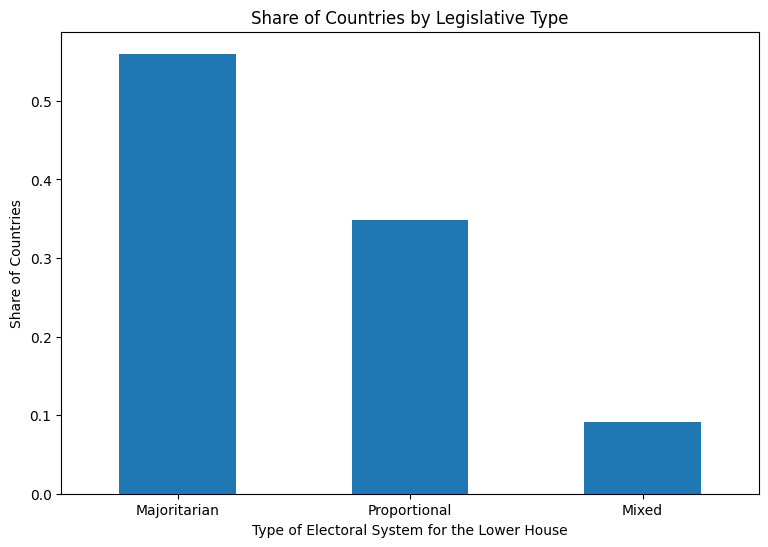

In [3]:
# Let us restrict our attention to democracies, specifically those for whom bmr_democracy is 1 
# es_df_dem = es_df_full[es_df['bmr_democracy'] == 1]

# Let us plot the share of countries  by legislative_type (type of electoral system for the lower house)
es_df_full['legislative_type'].value_counts(normalize=True).plot(kind='bar', figsize=(9, 6))
plt.title('Share of Countries by Legislative Type')
# relabel the x-axis (1 = Majoritarian, 2 = Proportional, 3 = Mixed)
plt.xticks([0, 1, 2], ['Majoritarian', 'Proportional', 'Mixed'], rotation=0)
plt.xlabel('Type of Electoral System for the Lower House')
plt.ylabel('Share of Countries')

C:\Users\User\AppData\Local\Temp\ipykernel_12884\2622291242.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (leg_type, group) in enumerate(es_df_dem_pl.groupby('legislative_type')):


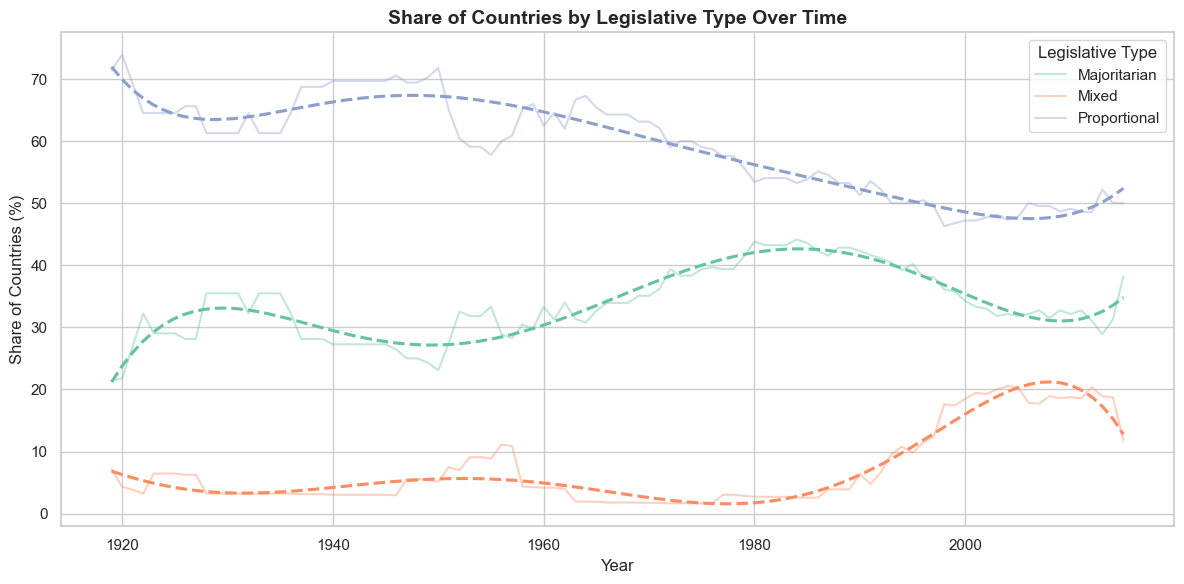

In [4]:
# Prepare data
es_df_dem_pl = (
    es_df_full
    .groupby(['year', 'legislative_type'])
    .size()
    .reset_index(name='count')
)
es_df_dem_pl['share'] = (
    es_df_dem_pl['count'] /
    es_df_dem_pl.groupby('year')['count'].transform('sum') * 100
)
leg_type_map = {1: 'Majoritarian', 2: 'Proportional', 3: 'Mixed'}
es_df_dem_pl['legislative_type'] = (
    es_df_dem_pl['legislative_type'].map(leg_type_map).astype('category')
)

# Set up plot
plt.figure(figsize=(12, 6))
sns.set_theme(style='whitegrid')

# Plot all in one go for consistency and better legend handling
palette = sns.color_palette("Set2")
for i, (leg_type, group) in enumerate(es_df_dem_pl.groupby('legislative_type')):
    sns.lineplot(data=group, x='year', y='share', label=leg_type, color=palette[i], alpha=0.4)
    sns.regplot(
        data=group, x='year', y='share',
        scatter=False, ci=None, order=6,
        color=palette[i], line_kws={'linestyle': '--'}
    )

# Final touches
plt.title('Share of Countries by Legislative Type Over Time', fontsize=14, weight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Share of Countries (%)', fontsize=12)
plt.legend(title='Legislative Type')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_12884\925331059.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  es_df_dem['country'] = es_df_dem['country'].replace({'West Germany': 'Germany'})


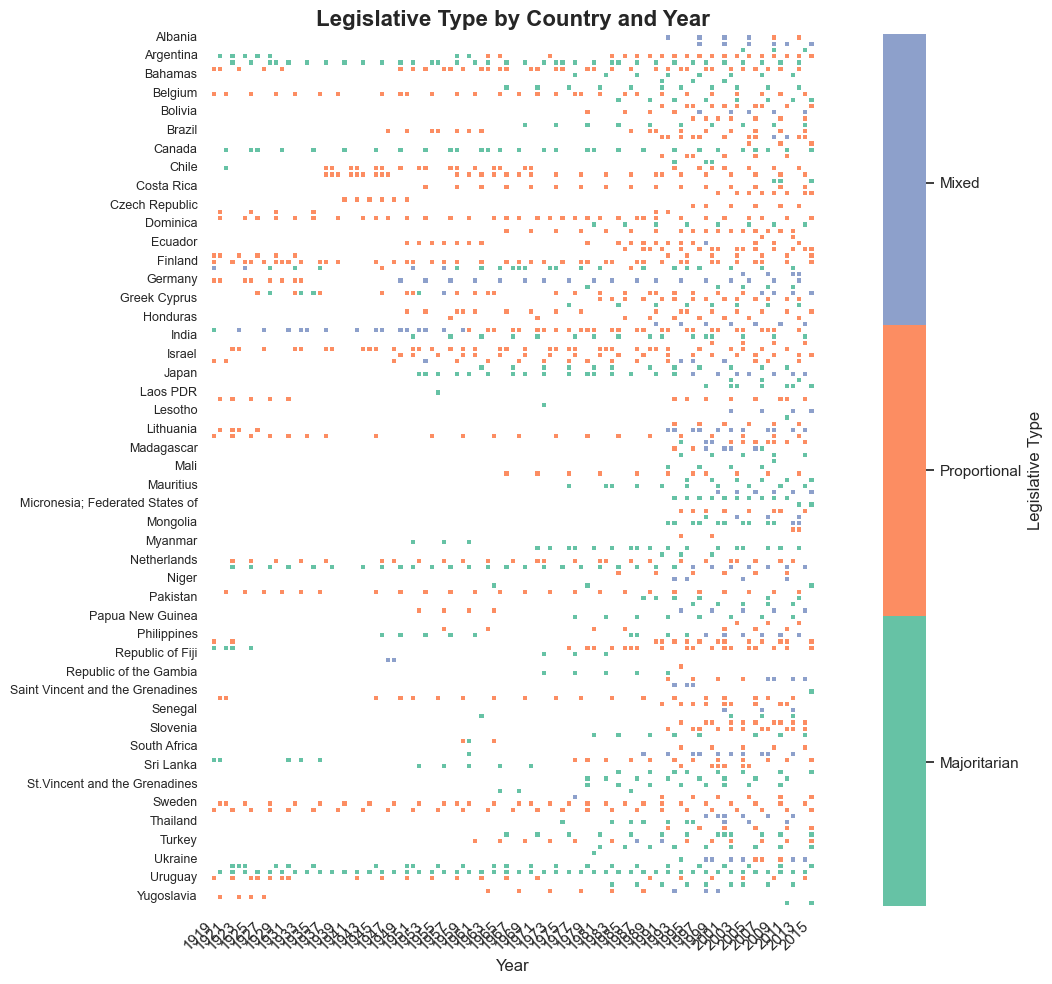

In [5]:
# Combine West Germany and Germany into one country
es_df_dem['country'] = es_df_dem['country'].replace({'West Germany': 'Germany'})

# Step 1: Ensure data is sorted properly
es_df_dem = es_df_dem.sort_values(['country', 'year'])

# Step 2: Forward-fill missing legislative_type for each country
es_df_dem['legislative_type'] = (
    es_df_dem.groupby('country')['legislative_type'].ffill()
)

# Pivot the DataFrame
es_df_dem_pivot = es_df_dem.pivot_table(
    index='country', columns='year', values='legislative_type', aggfunc='first'
)

# Define the color palette for categorical mapping
leg_type_map = {1: 'Majoritarian', 2: 'Proportional', 3: 'Mixed'}
palette = ['#66c2a5', '#fc8d62', '#8da0cb']  # Set2 colors

# Plot
plt.figure(figsize=(14, 10))
sns.set_theme(style="white")  # cleaner background

# Use a discrete colormap
cmap = sns.color_palette(palette, as_cmap=True)

# Plot heatmap
ax = sns.heatmap(
    es_df_dem_pivot,
    cmap=cmap,
    vmin=1, vmax=3,
    cbar_kws={'label': 'Legislative Type'},
    linewidths=0.3,
    linecolor='white',
    square=True
)

# Fix colorbar ticks
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([1.33, 2.0, 2.66])
colorbar.set_ticklabels(['Majoritarian', 'Proportional', 'Mixed'])

# Final touches
plt.title('Legislative Type by Country and Year', fontsize=16, weight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(None, fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()